In [ ]:
import torch
import torch.nn as nn

# ==========================================
# 1. 입력 데이터 및 모델 파라미터 준비
# ==========================================

# 2개의 샘플과 각 샘플당 10개의 특징(Feature)을 가진 입력 데이터 테노(Tensor) 생성
x_train = torch.randn(2, 10)

# CrossEntropyLoss 계산을 위한 정답 타겟 레이블 설정 (클래스 0, 클래스 1)
y_train = torch.tensor([0, 1])

# 입력 차원 10, 출력 차원 2를 갖는 선형 레이어(Fully Connected Layer) 모델 생성
model = nn.Linear(10, 2)


# ==========================================
# 2. 순전파 (Forward) 연산 수행
# ==========================================

# 입력 데이터(x_train)를 모델에 전달하여 선형 연산(X * W^T + b) 수행 후 출력 산출
outputs = model(x_train)

# 분류 문제를 위한 교차 엔트로피(CrossEntropy) 손실 함수 객체 생성
criterion = nn.CrossEntropyLoss()

# 모델의 예측 출력값(outputs)과 실제 정답(y_train) 비교를 통한 최종 손실(Loss) 스칼라값 계산
loss = criterion(outputs, y_train)


# ==========================================
# 3. 중간 노드(Non-leaf Tensor) 그래디언트 보존 설정
# ==========================================

# PyTorch 메모리 관리 규칙상 원래는 제거되는 중간 연산 결과(outputs)의 기울기를 역전파 후에도 보존하도록 설정
outputs.retain_grad()

# 최종 계산된 손실(loss) 객체의 기울기를 역전파 후에도 메모리에 유지하도록 설정 (UserWarning 방지)
loss.retain_grad()


# ==========================================
# 4. 역전파 (Backward) 수행 및 미분값(Gradient) 계산
# ==========================================

# 연산 그래프(Computational Graph)를 역방향으로 추적하며 모든 파라미터의 기울기(dLoss/dParam) 자동 계산
loss.backward()


# ==========================================
# 5. 계산된 기울기(Gradient) 상태 확인
# ==========================================

print(f'outputs: {outputs}')

# Loss 자체에 대한 자기 자신의 미분값 (dLoss/dLoss = 1.0) 출력
print("loss.grad           :", loss.grad)

# outputs 노드로 흘러들어온 그래디언트 (dLoss/dOutputs) 출력
print("outputs.grad        :", outputs.grad)

# 손실에 대한 모델 가중치(Weight)의 미분값 (dLoss/dW) 출력
print("model.weight.grad   :", model.weight.grad)

# 손실에 대한 모델 편향(Bias)의 미분값 (dLoss/dB) 출력
print("model.bias.grad     :", model.bias.grad)


# ==========================================
# 6. 가중치 업데이트 (수동 경사하강법 - SGD)
# ==========================================

# 가중치 업데이트 전 기존 가중치 값을 복사(clone)하여 저장 (변화량 측정용)
W_old = model.weight.clone()

# 학습률(Learning Rate, lr) 설정
learning_rate = 0.1

# 파이토치의 자동 미분(Autograd) 추적 기능을 잠시 비활성화하여 가중치 수정 연산이 그래프에 기록되지 않도록 함
with torch.no_grad():
    # 경사하강법 공식: W_new = W_old - (Learning_Rate * Gradient)
    model.weight -= learning_rate * model.weight.grad
    
    # 편향 업데이트: B_new = B_old - (Learning_Rate * Gradient)
    model.bias -= learning_rate * model.bias.grad

# 경사하강법으로 업데이트가 완료된 새로운 가중치 참조
W_new = model.weight

# 업데이트 후의 가중치 행렬 중 첫 번째 행의 앞쪽 3개 원소 출력
print("\n업데이트 후 Weight (W_new)[0][:3] :", W_new[0][:3])

# (업데이트 후 가중치 - 업데이트 전 가중치)를 계산하여 실제 가중치 변화량 출력
print("실제 반영된 변화량 (W_new - W_old)[0][:3] :", (W_new - W_old)[0][:3])

loss.grad           : tensor(1.)
outputs.grad        : tensor([[-0.3717,  0.3717],
        [ 0.3446, -0.3446]])
model.weight.grad   : tensor([[-0.9295,  0.5178, -0.5886,  0.3305,  0.4761,  0.4156, -0.0674,  0.4749,
         -0.1948,  0.3184],
        [ 0.9295, -0.5178,  0.5886, -0.3305, -0.4761, -0.4156,  0.0674, -0.4749,
          0.1948, -0.3184]])
model.bias.grad     : tensor([-0.0271,  0.0271])

업데이트 후 Weight (W_new)[0][:3] : tensor([-0.1160,  0.2543,  0.0091], grad_fn=<SliceBackward0>)
실제 반영된 변화량 (W_new - W_old)[0][:3] : tensor([ 0.0929, -0.0518,  0.0589], grad_fn=<SliceBackward0>)


: 

sklearn으로 MNIST 데이터를 로드하는 중...
Epoch [1/5], Loss: 0.1294
Epoch [2/5], Loss: 0.0307
Epoch [3/5], Loss: 0.0137
Epoch [4/5], Loss: 0.0118
Epoch [5/5], Loss: 0.0110


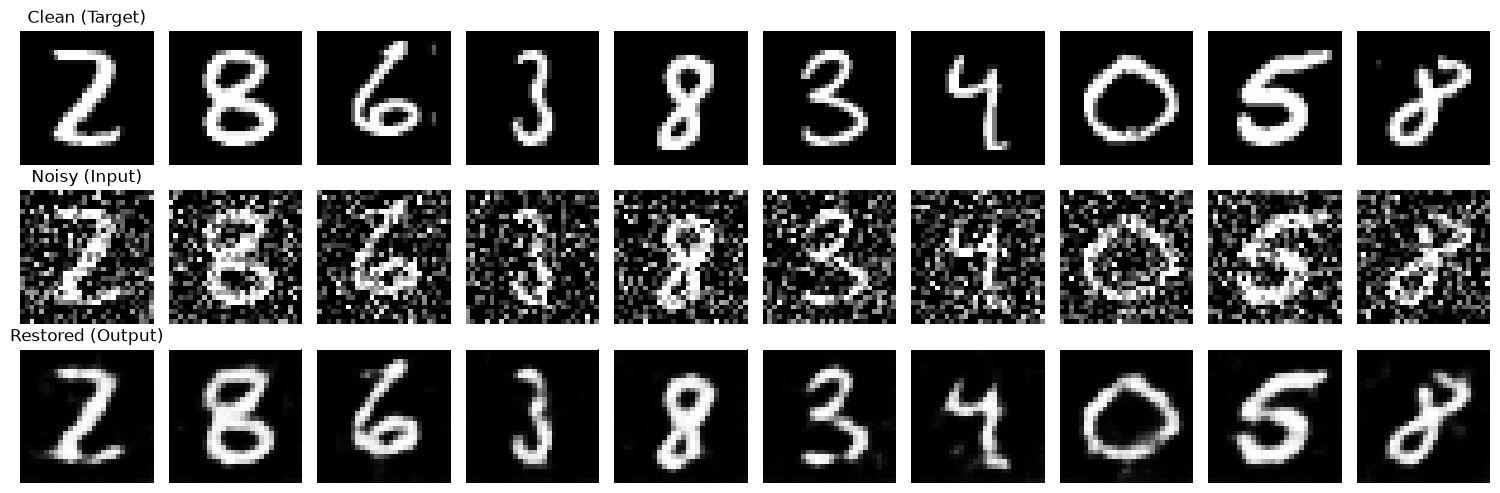

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ==========================================
# 1. sklearn을 통한 MNIST 데이터 로드 및 전처리
# ==========================================

# OpenML 플랫폼에서 'mnist_784' 데이터셋을 다운로드 중임을 안내
print("sklearn으로 MNIST 데이터를 로드하는 중...")

# OpenML로부터 MNIST 데이터셋 로드 (라벨 y는 사용하지 않고 이미지 특징 X만 추출, numpy 배열 형태로 반환)
X, _ = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# 0~255 범위의 픽셀값을 0.0~1.0 사이로 정규화하고, 학습 속도 향상을 위해 상위 10,000개 데이터만 슬라이싱
X = (X / 255.0)[:10000]

# 1차원 배열(784) 형태인 이미지를 PyTorch Conv2d 입력을 위한 4차원 형태 (배치수 N, 채널수 C=1, 높이 H=28, 너비 W=28)로 변환
X = X.reshape(-1, 1, 28, 28).astype(np.float32)

# 데이터를 학습용(80%, 8,000개)과 테스트용(20%, 2,000개)으로 분할 (시드 고정 random_state=42)
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Numpy 배열을 PyTorch Tensor로 변환한 뒤, 파이토치 TensorDataset 객체로 생성
train_dataset = TensorDataset(torch.from_numpy(X_train))
test_dataset = TensorDataset(torch.from_numpy(X_test))

# 학습용 데이터를 배치 단위(64개)로 묶고 매 에포크마다 셔플하도록 DataLoader 설정
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 테스트 데이터를 평가 시 사용할 배치 단위(10개)로 순서대로 가져오도록 DataLoader 설정
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)


# ==========================================
# 2. CNN (Convolutional) Denoising Autoencoder 모델 정의
# ==========================================

# 파이토치의 nn.Module을 상속받아 합성곱 기반 디노이징 오토인코더 클래스 정의
class ConvDenoisingAutoencoder(nn.Module):
    def __init__(self):
        # 부모 클래스(nn.Module)의 초기화 메서드 호출
        super(ConvDenoisingAutoencoder, self).__init__()
        
        # [인코더] 고차원 이미지를 입력받아 핵심 특징(Latent Vector)으로 압축하는 신경망 정의
        self.encoder = nn.Sequential(
            # 입력: (Batch, 1, 28, 28) -> 출력: (Batch, 16, 14, 14) (채널 확대 및 공간 차원 절반 축소)
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), 
            # 비선형성을 부여하기 위한 ReLU 활성화 함수 적용
            nn.ReLU(),
            # 입력: (Batch, 16, 14, 14) -> 출력: (Batch, 32, 7, 7) (잠재 공간으로 최종 압축)
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), 
            # 비선형 활성화 함수 적용
            nn.ReLU()
        )
        
        # [디코더] 압축된 잠재 공간의 특징 표현을 원래 이미지 해상도로 복원하는 신경망 정의
        self.decoder = nn.Sequential(
            # 입력: (Batch, 32, 7, 7) -> 출력: (Batch, 16, 14, 14) (전치 합성곱을 통한 해상도 복원)
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), 
            # 비선형 활성화 함수 적용
            nn.ReLU(),
            # 입력: (Batch, 16, 14, 14) -> 출력: (Batch, 1, 28, 28) (원본 이미지 크기로 재구성)
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1), 
            # 최종 픽셀 출력을 원본 정규화 범위인 0.0~1.0 사이로 제한하기 위한 Sigmoid 적용
            nn.Sigmoid()
        )

    # 순전파(Forward) 함수: 입력을 인코더에 통과시켜 압축한 뒤, 디코더를 통과시켜 복원값 반환
    def forward(self, x):
        return self.decoder(self.encoder(x))

# GPU 사용 가능 여부를 감지하여 연산 디바이스(cuda 또는 cpu) 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 인스턴스 생성 및 설정된 연산 디바이스(GPU/CPU)로 이관
model = ConvDenoisingAutoencoder().to(device)

# 복원된 이미지와 원본 이미지 간의 오차를 측정할 평균 제곱 오차(MSE) 손실 함수 선언
criterion = nn.MSELoss()

# Adam 최적화 알고리즘 객체 생성 (학습률 lr=0.001 설정)
optimizer = optim.Adam(model.parameters(), lr=0.001)


# ==========================================
# 3. 노이즈 추가 함수 및 학습 루프
# ==========================================

# 입력 이미지에 가우시안 무작위 노이즈를 더해주는 함수 정의
def add_noise(images, noise_factor=0.4):
    # 이미지 Tensor 크기와 동일한 형태의 표준정규분포 노이즈를 더함
    noisy_images = images + noise_factor * torch.randn_like(images)
    # 노이즈가 더해진 픽셀값이 0.0 미만이나 1.0 초과가 되지 않도록 범위를 제한(Clipping)
    return torch.clamp(noisy_images, 0.0, 1.0)

# 전체 학습 데이터셋 반복 횟수(Epoch) 설정
epochs = 5

# 에포크 수만큼 학습 반복 수행
for epoch in range(epochs):
    # 각 에포크의 전체 손실 합을 누적할 변수 초기화
    running_loss = 0.0
    
    # DataLoader로부터 미니배치 단위로 데이터를 꺼내어 학습 진행
    for batch in train_loader:
        # 손실 비교를 위한 '깨끗한 원본 이미지(Target)'를 디바이스로 이관
        clean_images = batch[0].to(device)
        
        # 원본 이미지에 노이즈를 주입하여 '입력용 노이즈 이미지(Input)' 생성 후 디바이스로 이관
        noisy_images = add_noise(clean_images, noise_factor=0.4).to(device)
        
        # [Forward] 노이즈 이미지를 오토인코더 모델에 통과시켜 복원 이미지 생성
        outputs = model(noisy_images)
        
        # [Loss] 모델이 복원한 이미지(outputs)와 노이즈가 없는 원본 이미지(clean_images) 사이의 손실 계산
        loss = criterion(outputs, clean_images)
        
        # [Optimization] 매 스텝마다 누적되어 있던 이전 그래디언트를 0으로 초기화
        optimizer.zero_grad()
        # [Backward] 손실에 대한 모델 파라미터의 역전파 기울기(Gradient) 계산
        loss.backward()
        # [Step] 계산된 기울기를 바탕으로 가중치 및 편향 파라미터 업데이트
        optimizer.step()
        
        # 배치별 손실값을 전체 데이터 개수 단위로 누적 합산
        running_loss += loss.item() * clean_images.size(0)
        
    # 현재 에포크의 평균 손실값 계산 및 출력
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(X_train):.4f}")


# ==========================================
# 4. 시각화 (원본 vs 노이즈 입력 vs 복원 결과)
# ==========================================

# 모델을 평가 모드로 전환 (Dropout, BatchNorm 등의 레이어가 있을 경우 평가 동작 모드로 적용)
model.eval()

# 추론 시에는 미분 계산(Autograd 메모리 할당)을 비활성화하여 연산 속도 향상 및 메모리 절약
with torch.no_grad():
    # 테스트 DataLoader에서 첫 번째 미니배치(10개)만 추출
    for batch in test_loader:
        # 테스트 원본 이미지를 디바이스로 이관
        clean_images = batch[0].to(device)
        # 테스트 이미지에도 동일하게 노이즈 추가
        noisy_images = add_noise(clean_images, noise_factor=0.4).to(device)
        # 노이즈 제거 모델을 통해 최종 복원 이미지 생성
        restored_images = model(noisy_images)
        # 1개 배치(10개)만 처리 후 반복문 탈출
        break

# 시각화를 위해 PyTorch Tensor를 GPU 메모리에서 CPU로 이동시키고, 1차원 채널 축 제거(.squeeze) 후 Numpy 배열로 변환
clean_images = clean_images.cpu().squeeze().numpy()
noisy_images = noisy_images.cpu().squeeze().numpy()
restored_images = restored_images.cpu().squeeze().numpy()

# 3행 10열 형태의 matplotlib 서브플롯 그리드 생성
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

# 10개의 샘플 이미지를 순회하며 시각화 수행
for i in range(10):
    # 1행: 깨끗한 원본 이미지 (Target) 출력
    axes[0, i].imshow(clean_images[i], cmap='gray')
    axes[0, i].axis('off') # 눈금 및 축 표시 제거
    if i == 0: axes[0, i].set_title("Clean (Target)") # 첫 번째 열 상단에 타이틀 표기

    # 2행: 노이즈가 주입된 입력 이미지 (Input) 출력
    axes[1, i].imshow(noisy_images[i], cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("Noisy (Input)")

    # 3행: 모델에 의해 노이즈가 제거 및 복원된 이미지 (Output) 출력
    axes[2, i].imshow(restored_images[i], cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Restored (Output)")

# 서브플롯 간 여백 정돈 후 화면에 결과 그래프 출력
plt.tight_layout()
plt.show()

Epoch [1/5], Loss: 0.1174
Epoch [2/5], Loss: 0.1120
Epoch [3/5], Loss: 0.1120
Epoch [4/5], Loss: 0.1120
Epoch [5/5], Loss: 0.1120


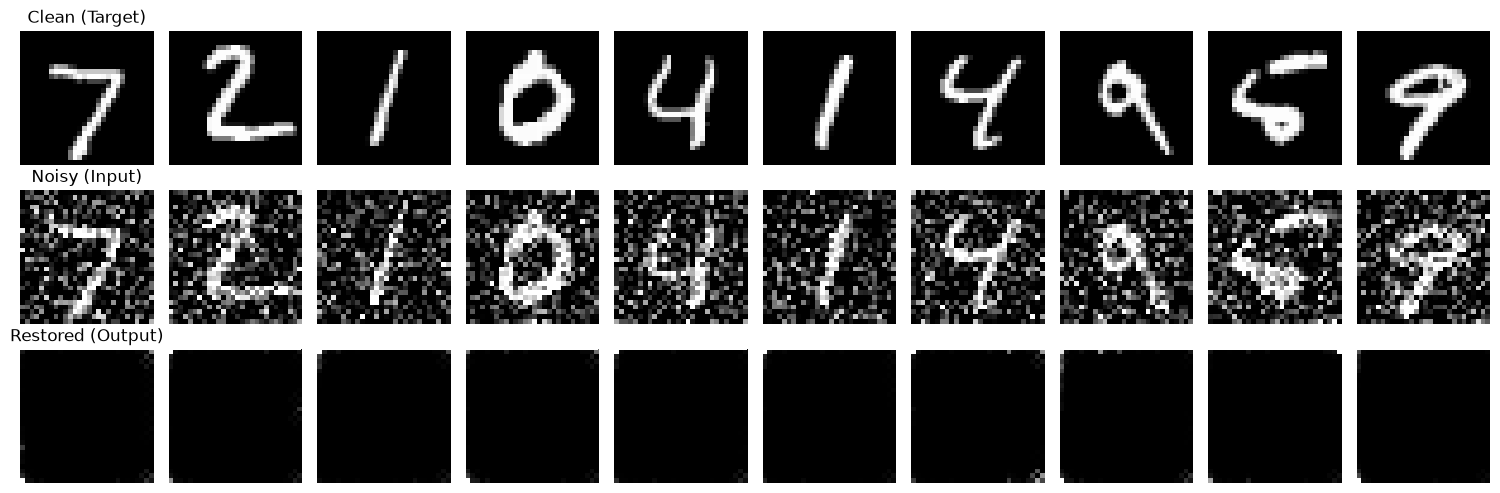

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ===============================================
# 1. Convolutional Denoising Autoencoder 모델 정의
# ===============================================
class ConvDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(ConvDenoisingAutoencoder, self).__init__()
        
        # [인코더] 노이즈가 섞인 고차원 이미지를 저차원 잠재 공간으로 압축
        # 입력: (Batch, 1, 28, 28)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # -> (Batch, 16, 14, 14)
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # -> (Batch, 32, 7, 7)
            nn.ReLU()
        )
        
        # [디코더] 저차원 잠재 공간에서 노이즈가 제거된 깨끗한 원본 이미지 크기로 재구성
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # -> (Batch, 16, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (Batch, 1, 28, 28)
            nn.Sigmoid() # 픽셀값을 0~1 사이로 정규화
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


# ==========================================
# 2. 데이터셋 로드 및 환경 설정
# ==========================================
# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MNIST 데이터셋 불러오기 (0~1 범위의 Tensor 변환)
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

# 모델, 손실 함수, 최적화 기구 초기화
model = ConvDenoisingAutoencoder().to(device)
criterion = nn.MSELoss() # 복원 오차 측정을 위한 MSE 손실 함수
optimizer = optim.Adam(model.parameters(), lr=0.001)


# ==========================================
# 3. 노이즈 추가 함수 정의
# ==========================================
def add_noise(images, noise_factor=0.4):
    """
    이미지 테노에 가우시안 노이즈를 더하고 0~1 범위를 벗어나지 않도록 클리핑합니다.
    """
    noisy_images = images + noise_factor * torch.randn_like(images)
    noisy_images = torch.clamp(noisy_images, 0.0, 1.0)
    return noisy_images


# ==========================================
# 4. 모델 학습 (Training Loop)
# ==========================================
epochs = 5

for epoch in range(epochs):
    running_loss = 0.0
    for images, _ in train_loader:
        # 깨끗한 원본 이미지 (정답 Target으로 사용)
        clean_images = images.to(device)
        
        # 의도적으로 노이즈를 섞은 이미지 (입력값 Input으로 사용)
        noisy_images = add_noise(clean_images, noise_factor=0.4).to(device)
        
        # [Forward] 노이즈 이미지를 모델에 통과시켜 복원 이미지 생성
        outputs = model(noisy_images)
        
        # [Loss] 복원된 이미지(outputs)와 '깨끗한 원본 이미지(clean_images)' 간의 차이 계산
        loss = criterion(outputs, clean_images)
        
        # [Backward & Optimization]
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * clean_images.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")


# ==========================================
# 5. 결과 시각화 (원본 vs 노이즈 입력 vs 복원 결과)
# ==========================================
model.eval()
with torch.no_grad():
    # 테스트 데이터 중 1개 배치를 가져옴
    for clean_images, _ in test_loader:
        clean_images = clean_images.to(device)
        noisy_images = add_noise(clean_images, noise_factor=0.4).to(device)
        
        # 노이즈가 제거된 복원 이미지 출력
        restored_images = model(noisy_images)
        break

# 시각화를 위해 CPU로 이관 및 Numpy 변환
clean_images = clean_images.cpu().squeeze().numpy()
noisy_images = noisy_images.cpu().squeeze().numpy()
restored_images = restored_images.cpu().squeeze().numpy()

# matplotlib 그래프 출력
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for i in range(10):
    # 1행: 깨끗한 원본 이미지
    axes[0, i].imshow(clean_images[i], cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Clean (Target)")

    # 2행: 노이즈가 주입된 입력 이미지
    axes[1, i].imshow(noisy_images[i], cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("Noisy (Input)")

    # 3행: 모델이 복원해낸 이미지
    axes[2, i].imshow(restored_images[i], cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Restored (Output)")

plt.tight_layout()
plt.show()

In [ ]:
import random
import torch
import torch.nn as nn
import torch.optim as optim

# ==========================================
# 0. 디바이스 자동 설정 (CUDA, Apple Silicon MPS, CPU)
# ==========================================

# NVIDIA GPU 가속(CUDA)이 사용 가능한지 확인
if torch.cuda.is_available():
    device = torch.device("cuda")
# Apple Silicon Mac GPU 가속(MPS)이 사용 가능한지 확인
elif torch.backends.mps.is_available():
    device = torch.device("mps")
# 하드웨어 가속기를 사용할 수 없는 경우 CPU로 설정
else:
    device = torch.device("cpu")

# 현재 선택되어 사용 중인 연산 디바이스 출력
print(f"사용 중인 연산 디바이스: {device}")


# ==========================================
# 1. 데이터 전처리 (<EOS> 토큰 추가 및 단어장 구축)
# ==========================================

# 학습 및 시퀀스 복원 테스트에 사용할 문자열 데이터 리스트
sentences = ['hello', 'world', 'pytorch', 'autoencoder', 'seq2seq']

# 특수 토큰 인덱스 정의 (<PAD>: 길이 맞춤용, <SOS>: 디코더 시작용, <EOS>: 문장 종료용)
PAD_TOKEN, SOS_TOKEN, EOS_TOKEN = 0, 1, 2

# 전체 문장 데이터에서 중복 없는 알파벳 단어집합(Alphabet Character Set) 추출 및 정렬
char_set = sorted(list(set("".join(sentences))))

# 특수 토큰 3종을 기본 포함하여 각 문자별 고유 인덱스를 매핑하는 사전(char2idx) 생성
char2idx = {'<PAD>': PAD_TOKEN, '<SOS>': SOS_TOKEN, '<EOS>': EOS_TOKEN}
# 알파벳 문자에 대해 인덱스 3번부터 순차적으로 ID 부여
for idx, char in enumerate(char_set, start=3):
    char2idx[char] = idx

# 역방향 출력을 위한 인덱스-문자 매핑 사전(idx2char) 생성
idx2char = {idx: char for char, idx in char2idx.items()}
# 특수 토큰을 포함한 전체 단어장의 크기 구하기
vocab_size = len(char2idx)

# 입력받은 문자열을 인덱스 배열로 바꾸고, 맨 뒤에 종료 토큰(<EOS>)을 명시적으로 붙여 텐서로 변환하는 함수
def string_to_tensor(string):
    indices = [char2idx[char] for char in string] + [EOS_TOKEN]
    return torch.tensor(indices, dtype=torch.long, device=device)

# <EOS> 토큰이 추가되는 것을 고려해 배치 내 가장 긴 시퀀스의 길이 계산 (+1)
max_len = max(len(s) for s in sentences) + 1

# 지정된 최대 길이에 맞춰 부족한 공간의 뒤쪽에 <PAD> 토큰(0)을 채워 넣는 함수
def pad_sequence(tensor, max_length):
    padded = torch.zeros(max_length, dtype=torch.long, device=device)
    padded[:len(tensor)] = tensor
    return padded

# 전체 문장 리스트를 <EOS>와 <PAD>가 적용된 PyTorch 텐서 리스트로 변환
data_tensors = [pad_sequence(string_to_tensor(s), max_len) for s in sentences]
# 텐서 리스트를 하나의 미니배치 텐서로 결합 (Shape: [Batch_Size, Max_Len])
data_batch = torch.stack(data_tensors)


# ==========================================
# 2. Seq2Seq Autoencoder 신경망 모델 정의
# ==========================================

# [인코더] 시퀀스 데이터를 순차적으로 전달받아 고정된 크기의 잠재 벡터(Latent Context)로 압축하는 클래스
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        # 부모 신경망 클래스(nn.Module) 초기화
        super(Encoder, self).__init__()
        # 문자의 정수 인덱스를 연속적인 밀집 벡터로 바꿔주는 임베딩 레이어 생성 (PAD 토큰은 학습 제외)
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_TOKEN)
        # 시퀀스의 시간적 흐름을 학습할 단방향 LSTM 생성 (batch_first=True 설정)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        # 입력된 인덱스 텐서를 임베딩 공간의 벡터로 변환 (Shape: [Batch, Seq_Len, Emb_Dim])
        embedded = self.embedding(x)
        # LSTM에 통과시킨 후, 입력 전체의 핵심 정보를 축적한 마지막 시점의 hidden state 및 cell state 추출
        _, (hidden, cell) = self.lstm(embedded)
        # 인코더의 최종 은닉 상태(Context Vector) 반환
        return hidden, cell


# [디코더] 인코더의 은닉 상태를 시작 상태로 받아서 원본 시퀀스를 한 글자씩 차례로 재구성하는 클래스
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        # 부모 신경망 클래스 초기화
        super(Decoder, self).__init__()
        # 출력 단어장 차원 크기 저장
        self.output_dim = output_dim
        # 토큰 임베딩 레이어 생성
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_TOKEN)
        # 이전 시점의 상태를 넘겨받아 연산할 LSTM 레이어 생성
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        # LSTM 출력을 단어장 분류 로짓(Logits)으로 변환해 줄 선형 변환 레이어 생성
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_step, hidden, cell):
        # 현재 타임스텝의 1글자 입력 텐서를 임베딩 (Shape: [Batch, 1, Emb_Dim])
        embedded = self.embedding(input_step)
        # 이전 시점의 hidden 및 cell 상태를 이어받아 현재 시점 연산 수행
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        # 예측된 결과를 단어장 차원으로 투영 (Shape: [Batch, 1, Output_Dim])
        prediction = self.fc(output)
        # 현재 시점의 예측 로짓과 업데이트된 hidden, cell 상태 반환
        return prediction, hidden, cell


# [통합 Seq2Seq Autoencoder] 인코더와 디코더를 연결하고 학습 흐름을 제어하는 클래스
class Seq2SeqAutoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        # 부모 신경망 클래스 초기화
        super(Seq2SeqAutoencoder, self).__init__()
        # 인코더 객체 할당
        self.encoder = encoder
        # 디코더 객체 할당
        self.decoder = decoder

    def forward(self, src, teacher_forcing_ratio=0.5):
        # 배치 크기 구하기
        batch_size = src.size(0)
        # 최대 시퀀스 길이 구하기
        max_len = src.size(1)
        # 디코더의 출력 단어장 크기 구하기
        vocab_size = self.decoder.output_dim

        # 매 타임스텝별 예측 결과를 저장할 빈 텐서 메모리 할당
        outputs = torch.zeros(batch_size, max_len, vocab_size, device=device)

        # 1. 인코더에 원본 입력을 넣어 압축된 잠재 상태(hidden, cell) 추출
        hidden, cell = self.encoder(src)

        # 2. 디코더의 첫 타임스텝 입력으로 <SOS> 토큰 준비 (Shape: [Batch, 1])
        decoder_input = torch.tensor([[SOS_TOKEN]] * batch_size, device=device)

        # 3. 시퀀스의 최대 길이만큼 순차적으로 한 스텝씩 복원 반복 연산
        for t in range(max_len):
            # 디코더 연산 수행하여 현재 스텝의 예측값과 다음 hidden/cell 상태 획득
            prediction, hidden, cell = self.decoder(decoder_input, hidden, cell)
            # 현재 타임스텝의 예측값을 outputs 텐서에 기록
            outputs[:, t:t+1, :] = prediction

            # 지정된 확률(teacher_forcing_ratio)로 Teacher Forcing 기법 적용 여부 결정
            teacher_force = random.random() < teacher_forcing_ratio
            
            # 모델이 가장 높은 확률로 예측한 문자 토큰 인덱스 계산
            top1 = prediction.argmax(2)

            # Teacher Forcing 적용 시 실제 정답 토큰(src[:, t:t+1])을, 미적용 시 모델 예측값(top1)을 다음 입력으로 전달
            decoder_input = src[:, t:t+1] if teacher_force else top1

        # 전체 시퀀스 복원 결과 텐서 반환
        return outputs


# ==========================================
# 3. 하이퍼파라미터 및 학습 환경 설정
# ==========================================

# 문자 임베딩 공간 차원 크기
EMB_DIM = 16
# LSTM 은닉 상태 차원 크기 (Latent Vector 공간 크기)
HIDDEN_DIM = 32

# 인코더 객체 생성
encoder = Encoder(vocab_size, EMB_DIM, HIDDEN_DIM)
# 디코더 객체 생성
decoder = Decoder(vocab_size, EMB_DIM, HIDDEN_DIM)
# 통합 오토인코더 모델 생성 및 지정 연산 디바이스(CPU/GPU/MPS)로 이관
model = Seq2SeqAutoencoder(encoder, decoder).to(device)

# 손실 함수 설정 (<PAD> 토큰 부분의 손실은 가중치 계산에서 제외 처리)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)
# 가중치 업데이트용 Adam 최적화 기구 선언 (학습률 0.01)
optimizer = optim.Adam(model.parameters(), lr=0.01)


# ==========================================
# 4. 모델 학습 루프 (Training Loop)
# ==========================================

# 총 학습 에포크 수 설정
epochs = 300

# 에포크 수만큼 반복 학습 수행
for epoch in range(1, epochs + 1):
    # 모델을 학습 동작 모드로 전환
    model.train()
    # 경사하강법 계산을 위해 이전 스텝의 기울기(Gradient)를 0으로 초기화
    optimizer.zero_grad()

    # [Forward] 입력 데이터를 모델에 통과시켜 복원 시도 (Teacher Forcing 50% 적용)
    output = model(data_batch, teacher_forcing_ratio=0.5)
    
    # CrossEntropyLoss 계산을 위해 차원을 평탄화 (Output: [Batch*Seq_Len, Vocab_Size], Target: [Batch*Seq_Len])
    loss = criterion(output.view(-1, vocab_size), data_batch.view(-1))

    # [Backward] 오차 역전파를 수행하여 각 파라미터의 기울기 계산
    loss.backward()
    # [Step] 계산된 기울기 방향으로 가중치 업데이트
    optimizer.step()

    # 50 에포크마다 현재의 손실(Loss) 값 출력
    if epoch % 50 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item():.4f}")


# ==========================================
# 5. 복원 결과 검증 및 출력
# ==========================================

# 모델을 평가 동작 모드로 전환
model.eval()

# 추론 과정 중 자동 미분(Autograd) 기능을 끄고 메모리 연산 절약
with torch.no_grad():
    # 평가 추론 시에는 Teacher Forcing을 꺼서(0.0) Pure Autoregressive 자가 예측 진행
    reconstructed_logits = model(data_batch, teacher_forcing_ratio=0.0)
    # 각 타임스텝별 가장 높은 확률을 갖는 토큰의 인덱스 선택
    predicted_indices = reconstructed_logits.argmax(2)

# 결과 구분 안내 문구 출력
print("\n=== 복원 결과 확인 ===")
# 학습용 데이터셋 전체를 순회하며 복원 상태 비교
for i in range(len(sentences)):
    # 원래 원본 단어 추출
    original_str = sentences[i]

    # 복원된 문자를 저장할 리스트 초기화
    pred_chars = []
    # 타임스텝별 예측 인덱스를 하나씩 검사
    for idx in predicted_indices[i]:
        token_id = idx.item()
        # [핵심] 예측 중 문장 종료(<EOS>) 토큰이나 패딩(<PAD>) 토큰을 감지하면 즉시 조기 종료(break)
        if token_id in (EOS_TOKEN, PAD_TOKEN):
            break
        # 시작 토큰(<SOS>)이 아닌 경우에만 결과 문자 리스트에 추가
        if token_id != SOS_TOKEN:
            pred_chars.append(idx2char[token_id])

    # 문자 리스트를 하나의 결합 문자열로 결합
    pred_str = "".join(pred_chars)
    # 원본 단어와 복원된 단어를 포맷에 맞춰 출력
    print(f"원본: {original_str:<12} | 복원: {pred_str}")

사용 중인 연산 디바이스: cpu
Epoch [50/300], Loss: 0.2010
Epoch [100/300], Loss: 0.0175
Epoch [150/300], Loss: 0.0082
Epoch [200/300], Loss: 0.0051
Epoch [250/300], Loss: 0.0035
Epoch [300/300], Loss: 0.0026

=== 복원 결과 확인 ===
원본: hello        | 복원: hello
원본: world        | 복원: world
원본: pytorch      | 복원: pytorch
원본: autoencoder  | 복원: autoencoder
원본: seq2seq      | 복원: seq2seq


In [ ]:
import os
import re
import tarfile
import urllib.request
import random
import numpy as np
import torch
import torch.nn as nn 
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 한국어 형태소 분석을 위한 KoNLPy 불러오기
try:
    from konlpy.tag import Okt
    okt = Okt()
except ImportError:
    print("KoNLPy가 설치되어 있지 않습니다. '!uv add konlpy'를 먼저 실행해주세요.")

# -------------------------------------------------------------------
# 1. 환경 설정 및 난수 고정
# -------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)

# -------------------------------------------------------------------
# 2. 데이터 다운로드 및 압축 해제 (jungyeul/korean-parallel-corpora)
# -------------------------------------------------------------------
DATA_DIR = "data_ko_en"
os.makedirs(DATA_DIR, exist_ok=True)

TAR_URL = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"
TAR_PATH = os.path.join(DATA_DIR, "korean-english-park.train.tar.gz")

if not os.path.exists(TAR_PATH):
    print("데이터 다운로드를 시작합니다...")
    urllib.request.urlretrieve(TAR_URL, TAR_PATH)
    print("다운로드 완료!")

# Tar 파일 압축 해제 (DeprecationWarning 해결)
with tarfile.open(TAR_PATH, "r:gz") as tar:
    try:
        tar.extractall(path=DATA_DIR, filter='data')
    except TypeError:
        # Python 이전 버전 호환용
        tar.extractall(path=DATA_DIR)

KO_PATH = os.path.join(DATA_DIR, "korean-english-park.train.ko")
EN_PATH = os.path.join(DATA_DIR, "korean-english-park.train.en")

# -------------------------------------------------------------------
# 3. 데이터 읽기 및 텍스트 전처리 함수
# -------------------------------------------------------------------
def preprocess_korean(text):
    text = str(text).strip()
    text = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣ0-9?.!,¿]+", " ", text)
    text = re.sub(r"([?.!,¿])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def preprocess_english(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-zA-Z0-9?.!,¿]+", " ", text)
    text = re.sub(r"([?.!,¿])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

NUM_SAMPLES = 10000

with open(KO_PATH, "r", encoding="utf-8") as f:
    raw_ko = [line.strip() for line in f.readlines()[:NUM_SAMPLES]]

with open(EN_PATH, "r", encoding="utf-8") as f:
    raw_en = [line.strip() for line in f.readlines()[:NUM_SAMPLES]]

encoder_texts = []
decoder_input_texts = []
decoder_target_texts = []

for ko, en in zip(raw_ko, raw_en):
    ko_prep = preprocess_korean(ko)
    ko_tokens = okt.morphs(ko_prep)
    
    en_prep = preprocess_english(en)
    en_tokens = en_prep.split()
    
    if len(ko_tokens) == 0 or len(en_tokens) == 0:
        continue
        
    encoder_texts.append(ko_tokens)
    decoder_input_texts.append(["<sos>"] + en_tokens)
    decoder_target_texts.append(en_tokens + ["<eos>"])

print(f"로드된 최종 샘플 개수: {len(encoder_texts)}")

# -------------------------------------------------------------------
# 4. 단어 사전(Vocabulary) 구축
# -------------------------------------------------------------------
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"

def build_vocab(tokenized_sentences, add_special_tokens=True):
    vocab = set()
    for sentence in tokenized_sentences:
        for token in sentence:
            vocab.add(token)
    vocab = sorted(list(vocab))
    
    if add_special_tokens:
        base_tokens = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]
        vocab = base_tokens + [t for t in vocab if t not in base_tokens]
    else:
        vocab = [PAD_TOKEN, UNK_TOKEN] + [t for t in vocab if t not in [PAD_TOKEN, UNK_TOKEN]]
        
    w2i = {word: idx for idx, word in enumerate(vocab)}
    i2w = {idx: word for word, idx in w2i.items()}
    return w2i, i2w

src_to_index, index_to_src = build_vocab(encoder_texts, add_special_tokens=False)
tar_to_index, index_to_tar = build_vocab(decoder_input_texts + decoder_target_texts, add_special_tokens=True)

src_vocab_size = len(src_to_index)
tar_vocab_size = len(tar_to_index)

print("한국어(입력) 단어 집합 크기:", src_vocab_size)
print("영어(출력) 단어 집합 크기:", tar_vocab_size)

# -------------------------------------------------------------------
# 5. 정수 인코딩 및 패딩
# -------------------------------------------------------------------
def tokens_to_indices(tokens, vocab):
    return [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens]

def pad_sequences(sequences, max_len, pad_value):
    padded = []
    for seq in sequences:
        seq = seq[:max_len]
        padded.append(seq + [pad_value] * (max_len - len(seq)))
    return torch.tensor(padded, dtype=torch.long)

encoder_seqs = [tokens_to_indices(s, src_to_index) for s in encoder_texts]
decoder_in_seqs = [tokens_to_indices(s, tar_to_index) for s in decoder_input_texts]
decoder_tar_seqs = [tokens_to_indices(s, tar_to_index) for s in decoder_target_texts]

max_src_len = max(len(s) for s in encoder_seqs)
max_tar_len = max(len(s) for s in decoder_in_seqs)

encoder_input = pad_sequences(encoder_seqs, max_src_len, src_to_index[PAD_TOKEN])
decoder_input = pad_sequences(decoder_in_seqs, max_tar_len, tar_to_index[PAD_TOKEN])
decoder_target = pad_sequences(decoder_tar_seqs, max_tar_len, tar_to_index[PAD_TOKEN])

# -------------------------------------------------------------------
# 6. Dataset 및 DataLoader 구성
# -------------------------------------------------------------------
class TranslationDataset(Dataset):
    def __init__(self, enc_in, dec_in, dec_tar):
        self.enc_in = enc_in
        self.dec_in = dec_in
        self.dec_tar = dec_tar

    def __len__(self):
        return len(self.enc_in)

    def __getitem__(self, idx):
        return self.enc_in[idx], self.dec_in[idx], self.dec_tar[idx]

dataset = TranslationDataset(encoder_input, decoder_input, decoder_target)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

# -------------------------------------------------------------------
# 7. PyTorch Seq2Seq 모델 정의
# -------------------------------------------------------------------
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        return hidden, cell

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, trg, hidden, cell):
        embedded = self.embedding(trg)
        outputs, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        predictions = self.fc_out(outputs)
        return predictions, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg):
        hidden, cell = self.encoder(src)
        outputs, _, _ = self.decoder(trg, hidden, cell)
        return outputs

# -------------------------------------------------------------------
# 8. 모델 생성 및 학습 설정
# -------------------------------------------------------------------
EMBEDDING_DIM = 128
HIDDEN_UNITS = 256
EPOCHS = 10

encoder = Encoder(src_vocab_size, EMBEDDING_DIM, HIDDEN_UNITS, src_to_index[PAD_TOKEN])
decoder = Decoder(tar_vocab_size, EMBEDDING_DIM, HIDDEN_UNITS, tar_to_index[PAD_TOKEN])
model = Seq2Seq(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=tar_to_index[PAD_TOKEN])
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -------------------------------------------------------------------
# 9. 모델 학습 루프
# -------------------------------------------------------------------
print("\n--- 학습 시작 ---")
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for src, dec_in, dec_out in train_loader:
        src, dec_in, dec_out = src.to(device), dec_in.to(device), dec_out.to(device)

        optimizer.zero_grad()
        output = model(src, dec_in)

        output_dim = output.shape[-1]
        loss = criterion(output.reshape(-1, output_dim), dec_out.reshape(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch:02d}/{EPOCHS}] Train Loss: {avg_loss:.4f}")

# -------------------------------------------------------------------
# 10. 한국어 -> 영어 번역 테스트 함수 (수정 완료)
# -------------------------------------------------------------------
def translate_korean(sentence, model, max_len=30):
    model.eval()
    
    ko_prep = preprocess_korean(sentence)
    ko_tokens = okt.morphs(ko_prep)
    src_indices = tokens_to_indices(ko_tokens, src_to_index)
    src_tensor = torch.tensor(src_indices, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor)

    current_token = torch.tensor([[tar_to_index[SOS_TOKEN]]], dtype=torch.long).to(device)
    translated_tokens = []

    for _ in range(max_len):
        with torch.no_grad():
            output, hidden, cell = model.decoder(current_token, hidden, cell)

        next_token = output[:, -1, :].argmax(dim=-1).item()

        # <eos> 토큰을 만나면 생성 종료
        if next_token == tar_to_index[EOS_TOKEN]:
            break

        translated_tokens.append(index_to_tar.get(next_token, UNK_TOKEN))
        current_token = torch.tensor([[next_token]], dtype=torch.long).to(device)

    return " ".join(translated_tokens)

# 테스트 실행
test_sentence = "데이터를 통해 새로운 인공지능 모델을 학습시킵니다."
result = translate_korean(test_sentence, model)

print("\n--- 번역 결과 테스트 ---")
print("입력 한국어:", test_sentence)
print("번역된 영어:", result)

사용 장치: cpu
데이터 다운로드를 시작합니다...
다운로드 완료!
로드된 최종 샘플 개수: 10000
한국어(입력) 단어 집합 크기: 22277
영어(출력) 단어 집합 크기: 18521

--- 학습 시작 ---
Epoch [01/10] Train Loss: 7.0326
Epoch [02/10] Train Loss: 6.3152
Epoch [03/10] Train Loss: 6.0174
Epoch [04/10] Train Loss: 5.7877
Epoch [05/10] Train Loss: 5.5903
Epoch [06/10] Train Loss: 5.4200
Epoch [07/10] Train Loss: 5.2585
Epoch [08/10] Train Loss: 5.1085
Epoch [09/10] Train Loss: 4.9661
Epoch [10/10] Train Loss: 4.8277

--- 번역 결과 테스트 ---
입력 한국어: 데이터를 통해 새로운 인공지능 모델을 학습시킵니다.
번역된 영어: lag destruction do have been charged with the u . s .
